<div style="background: linear-gradient(135deg, #4C1D95 0%, #F5F3FF 100%); padding: 24px; border-radius: 12px; color: white; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1);">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Classroom Analysis</h1>
    <div style="background: rgba(255, 255, 255, 0.2); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Goal:</strong> Find trends in data set 1
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs3.pkl')

df = all_dfs['df']
clean_df = all_dfs['clean_df']
clean_df2 = all_dfs['clean_df2']
clean_df3 = all_dfs['clean_df3']

In [2]:
print(clean_df.columns.tolist())

['Building #', 'Grade', 'Subject', 'Teacher Years of Experience', 'Test Score Year 1', 'Test Score Year 2']


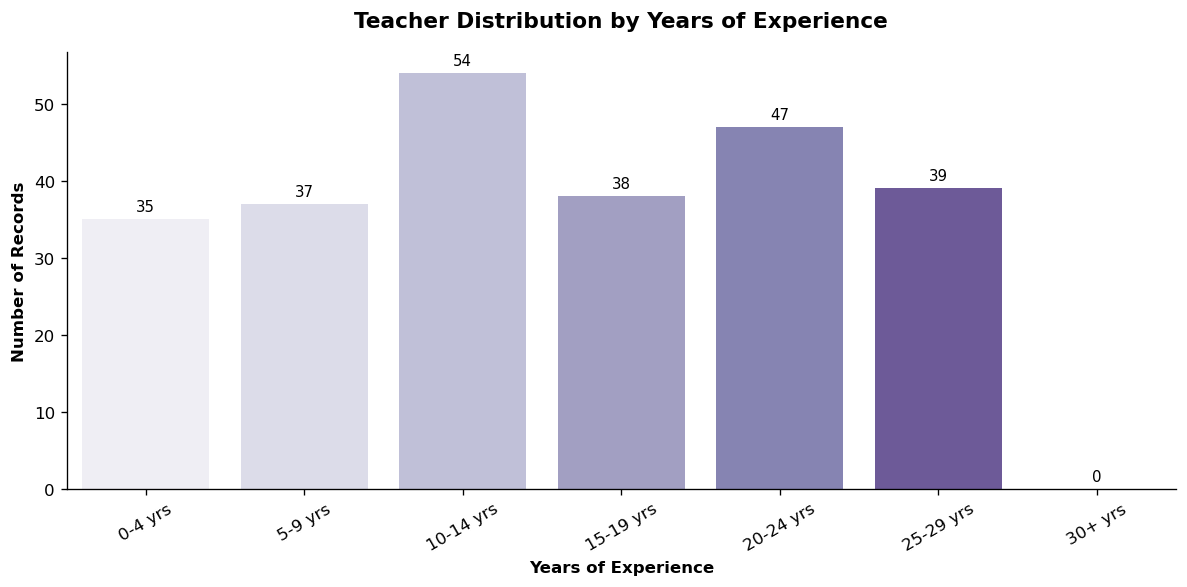

In [25]:
#bins&labels
bins = [-1, 5, 10, 15, 20, 25, 30, float("inf")]
labels = [
    "0-4 yrs",
    "5-9 yrs",
    "10-14 yrs",
    "15-19 yrs",
    "20-24 yrs",
    "25-29 yrs",
    "30+ yrs",
]

clean_df["Experience_Bin"] = pd.cut(
    clean_df["Teacher Years of Experience"], bins=bins, labels=labels
)

exp_counts = (
    clean_df.groupby("Experience_Bin", observed=False)
    .size()
    .reset_index(name="Teacher_Count")
)

#Format & plot
plt.figure(figsize=(10, 5), dpi=120)

ax = sns.barplot(
    data=exp_counts,
    x="Experience_Bin",
    y="Teacher_Count",
    hue="Experience_Bin",
    palette="Purples", 
    legend=False,
)

# Top of bars labelling
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

# Chart shape & labels
sns.despine(top=True, right=True)
plt.title(
    "Teacher Distribution by Years of Experience", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("Years of Experience", fontsize=10, fontweight="bold")
plt.ylabel("Number of Records", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

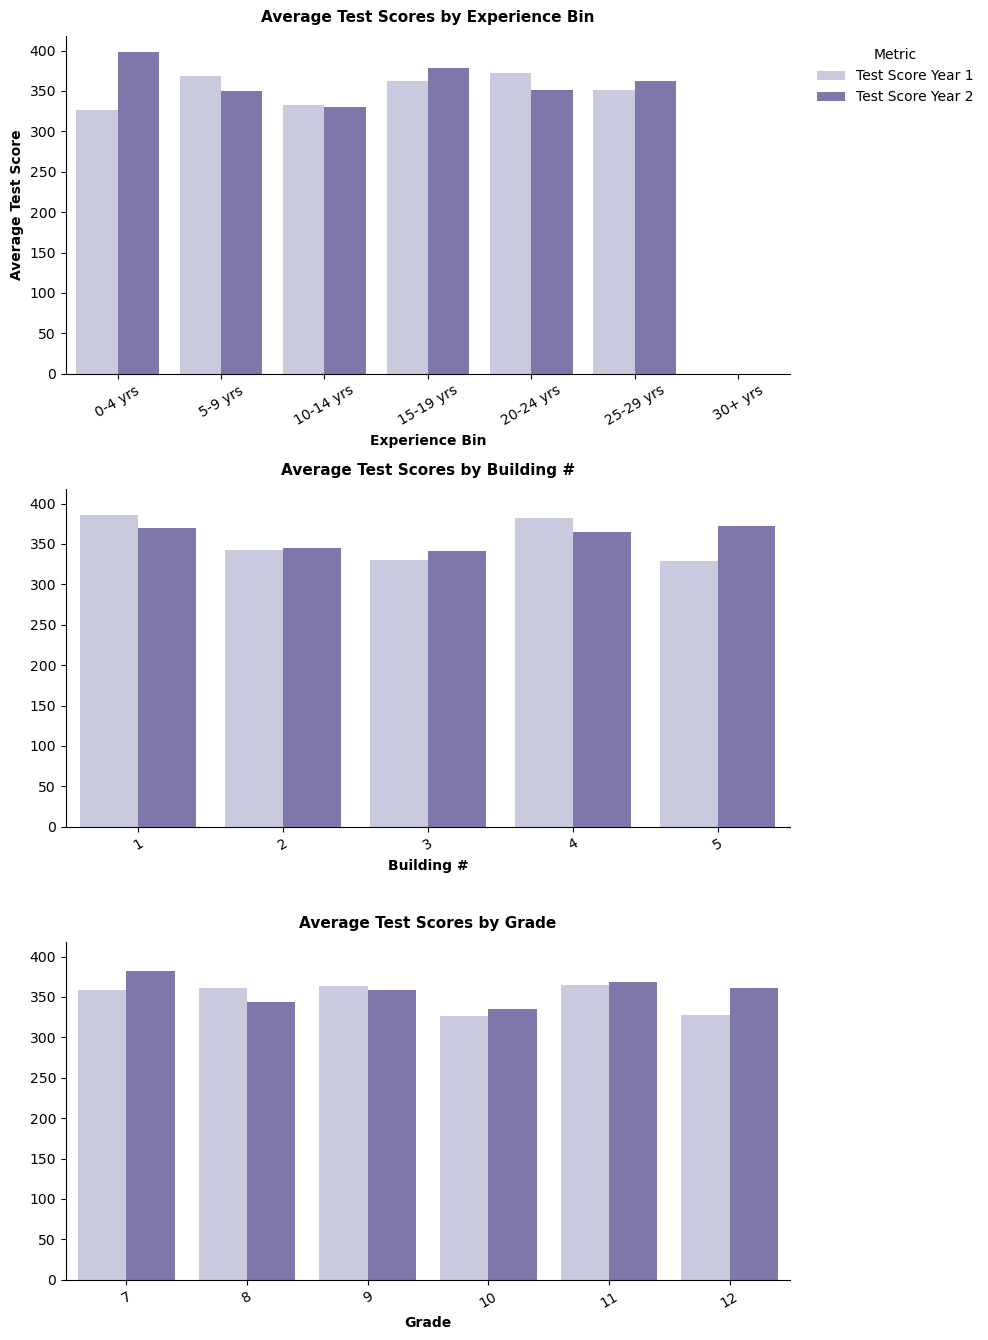

In [12]:
# variables
group_vars = ["Experience_Bin", "Building #", "Grade"]
active_vars = [var for var in group_vars if var in clean_df.columns]

#subplots
fig, axes = plt.subplots(
    len(active_vars), 1, figsize=(10, 4.5 * len(active_vars)), sharey=True
)

if len(active_vars) == 1:
    axes = [axes]

for i, var in enumerate(active_vars):
    # Group by category
    summary_df = (
        clean_df.groupby(var, observed=False)[["Test Score Year 1", "Test Score Year 2"]]
        .mean()
        .reset_index()
    )
    

    melted_df = summary_df.melt(
        id_vars=[var], 
        value_vars=["Test Score Year 1", "Test Score Year 2"],
        var_name="Test_Year", 
        value_name="Average_Score"
    )

    # Grouped bar chart - Year 1 and Year 2
    sns.barplot(
        data=melted_df,
        x=var,
        y="Average_Score",
        hue="Test_Year",
        palette="Purples",
        ax=axes[i],
        legend=(i == 0) # Only show legend on first
    )

    # Styling
    axes[i].set_title(
        f"Average Test Scores by {var.replace('_', ' ').title()}",
        fontsize=11,
        fontweight="bold",
        pad=10,
    )
    axes[i].set_xlabel(
        var.replace("_", " ").title(), fontsize=10, fontweight="bold"
    )
    axes[i].set_ylabel("Average Test Score" if i == 0 else "", fontsize=10, fontweight="bold")
    axes[i].tick_params(axis="x", rotation=30)
    
    sns.despine(ax=axes[i], top=True, right=True)
    # Legend cleanup - move to the right
    if i == 0:
        axes[i].legend(
            title="Metric", 
            frameon=False, 
            loc="upper left",
            bbox_to_anchor=(1.02, 1)  
        )

plt.tight_layout()
plt.show()

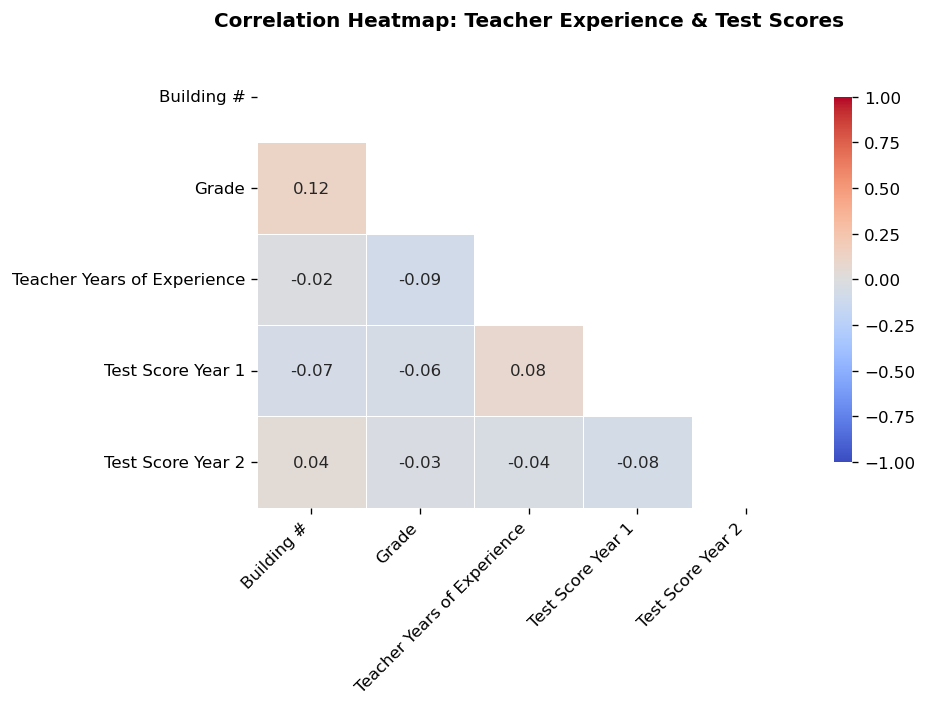

In [24]:
#teacher exp & test scores heatmap


numeric_cols = clean_df.select_dtypes(include=['number']).columns
corr_matrix = clean_df[numeric_cols].corr()

plt.figure(figsize=(8, 6), dpi=120)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)

#styling & Layout
plt.title("Correlation Heatmap: Teacher Experience & Test Scores", fontsize=12, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

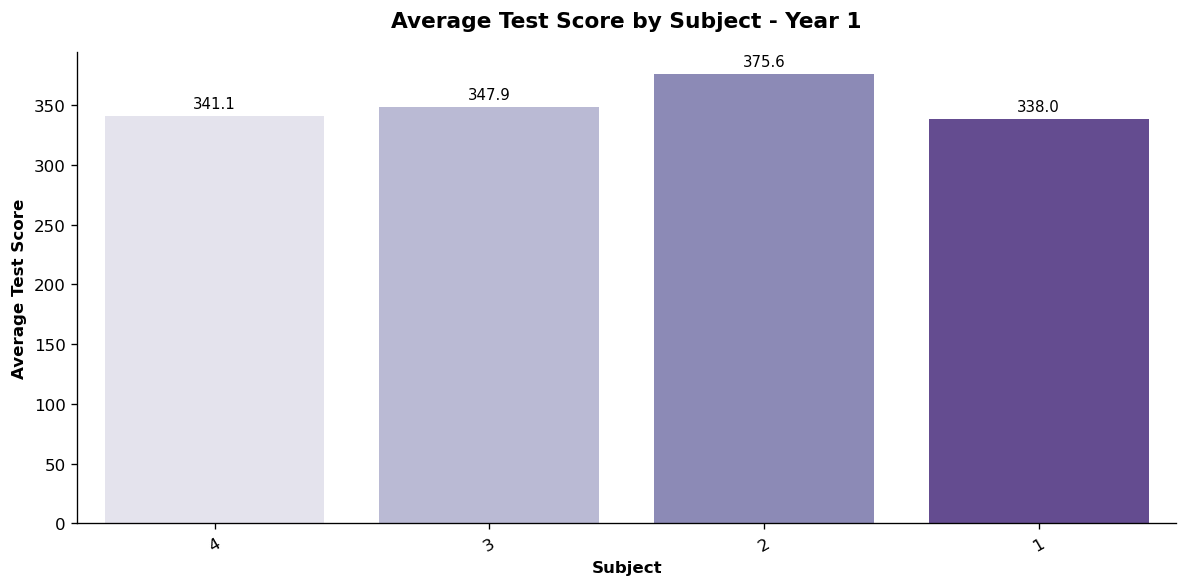

In [13]:
# Assuming your dataset has a 'Subject' column and a test score column (e.g., 'Test Score')
# Calculate average test score by subject
subject_scores = (
    clean_df.groupby("Subject", observed=False)["Test Score Year 1" ]
    .mean()
    .reset_index(name="Avg_Test_Score")
    .sort_values(by="Subject", ascending=False)
)

# Format & plot
plt.figure(figsize=(10, 5), dpi=120)

ax = sns.barplot(
    data=subject_scores,
    x="Subject",
    y="Avg_Test_Score",
    hue="Subject",
    palette="Purples",
    legend=False,
)

# Top of bars labelling (formatting as floating point numbers)
for container in ax.containers:
  ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

# Chart shape & labels
sns.despine(top=True, right=True)
plt.title(
    "Average Test Score by Subject - Year 1", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("Subject", fontsize=10, fontweight="bold")
plt.ylabel("Average Test Score", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

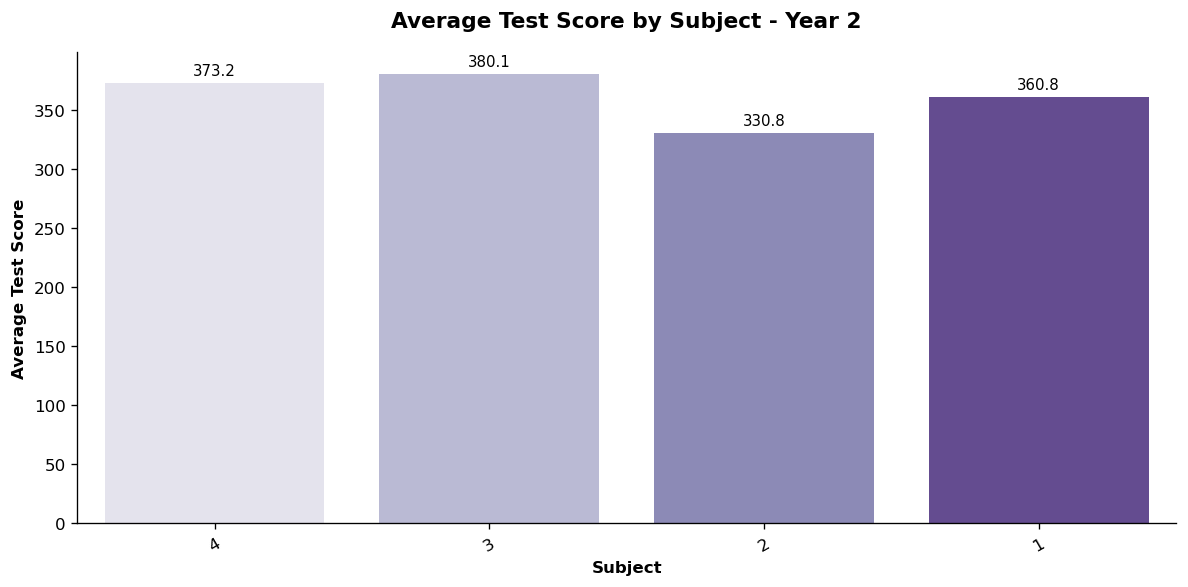

In [14]:
# Assuming your dataset has a 'Subject' column and a test score column (e.g., 'Test Score')
# Calculate average test score by subject
subject_scores = (
    clean_df.groupby("Subject", observed=False)["Test Score Year 2" ]
    .mean()
    .reset_index(name="Avg_Test_Score")
    .sort_values(by="Subject", ascending=False)
)

# Format & plot
plt.figure(figsize=(10, 5), dpi=120)

ax = sns.barplot(
    data=subject_scores,
    x="Subject",
    y="Avg_Test_Score",
    hue="Subject",
    palette="Purples",
    legend=False,
)

# Top of bars labelling (formatting as floating point numbers)
for container in ax.containers:
  ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

# Chart shape & labels
sns.despine(top=True, right=True)
plt.title(
    "Average Test Score by Subject - Year 2", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("Subject", fontsize=10, fontweight="bold")
plt.ylabel("Average Test Score", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

  Experience_Bin  Year_1_Avg  Year_2_Avg  Score_Jump
0        0-4 yrs  294.750000  326.000000   31.250000
1        5-9 yrs  419.230769  292.076923 -127.153846
2      10-14 yrs  316.666667  294.000000  -22.666667
3      15-19 yrs  406.230769  339.384615  -66.846154
4      20-24 yrs  432.933333  381.466667  -51.466667
5      25-29 yrs  346.100000  352.800000    6.700000
6        30+ yrs         NaN         NaN         NaN


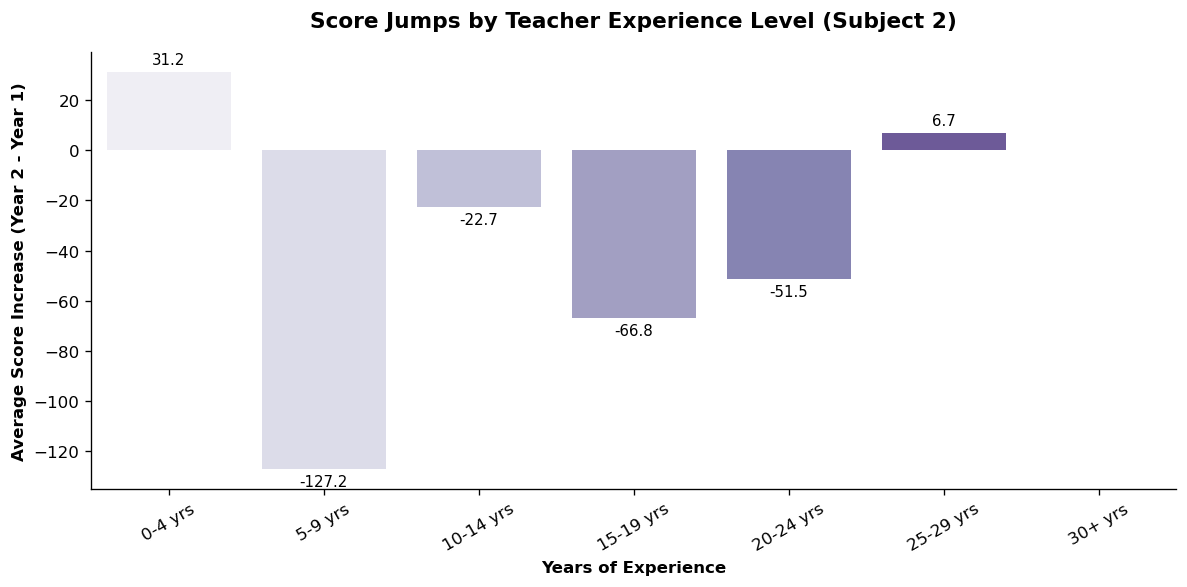

In [26]:
# 1. Filter for Subject '2' (as a string)
subject_2_df = clean_df[clean_df["Subject"] == "2"].copy()

# 2. Use your experience bins
bins = [-1, 5, 10, 15, 20, 25, 30, float("inf")]
labels = [
    "0-4 yrs",
    "5-9 yrs",
    "10-14 yrs",
    "15-19 yrs",
    "20-24 yrs",
    "25-29 yrs",
    "30+ yrs",
]
subject_2_df["Experience_Bin"] = pd.cut(
    subject_2_df["Teacher Years of Experience"], bins=bins, labels=labels
)

# 3. Calculate average scores by experience bin for both years
exp_yearly = (
    subject_2_df.groupby("Experience_Bin", observed=False)
    .agg(
        Year_1_Avg=("Test Score Year 1", "mean"),
        Year_2_Avg=("Test Score Year 2", "mean"),
    )
    .reset_index()
)

# 4. Calculate the jump
exp_yearly["Score_Jump"] = exp_yearly["Year_2_Avg"] - exp_yearly["Year_1_Avg"]

print(exp_yearly)

# 5. Plot the score jumps by experience bracket
plt.figure(figsize=(10, 5), dpi=120)

ax = sns.barplot(
    data=exp_yearly,
    x="Experience_Bin",
    y="Score_Jump",
    hue="Experience_Bin",
    palette="Purples",
    legend=False,
)

for container in ax.containers:
  ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)

sns.despine(top=True, right=True)
plt.title(
    "Score Jumps by Teacher Experience Level (Subject 2)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Years of Experience", fontsize=10, fontweight="bold")
plt.ylabel(
    "Average Score Increase (Year 2 - Year 1)", fontsize=10, fontweight="bold"
)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

  Experience_Bin  Record_Count
0        0-4 yrs             8
1        5-9 yrs            13
2      10-14 yrs            15
3      15-19 yrs            13
4      20-24 yrs            15
5        25+ yrs            10


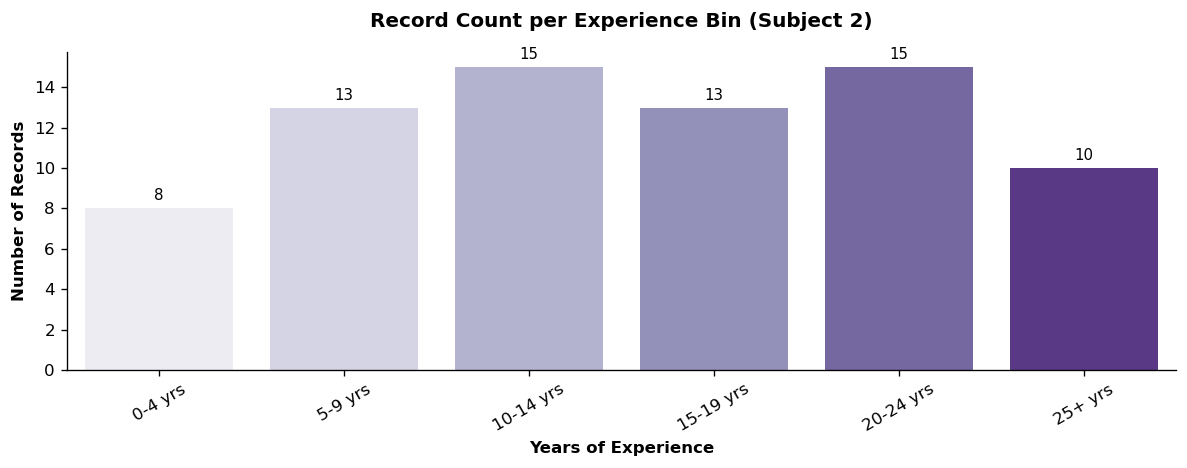

In [28]:
# Filter for Subject '2' and assign experience bins
subject_2_df = clean_df[clean_df["Subject"] == "2"].copy()

bins = [-1, 5, 10, 15, 20, 25, float("inf")]
labels = [
    "0-4 yrs",
    "5-9 yrs",
    "10-14 yrs",
    "15-19 yrs",
    "20-24 yrs",
    "25+ yrs"
]
subject_2_df["Experience_Bin"] = pd.cut(
    subject_2_df["Teacher Years of Experience"], bins=bins, labels=labels
)

# Count how many records/students fall into each experience bin
bin_counts = (
    subject_2_df.groupby("Experience_Bin", observed=False)
    .size()
    .reset_index(name="Record_Count")
)

print(bin_counts)

# Quick visualization of the counts
plt.figure(figsize=(10, 4), dpi=120)
ax = sns.barplot(
    data=bin_counts,
    x="Experience_Bin",
    y="Record_Count",
    hue="Experience_Bin",
    palette="Purples",
    legend=False,
)

for container in ax.containers:
  ax.bar_label(container, fmt="%d", padding=3, fontsize=9)

sns.despine(top=True, right=True)
plt.title(
    "Record Count per Experience Bin (Subject 2)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Years of Experience", fontsize=10, fontweight="bold")
plt.ylabel("Number of Records", fontsize=10, fontweight="bold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [45]:
from IPython.display import HTML, display

html_content = """
<div style="background: linear-gradient(135deg, #4C1D95 0%, #4C1D95 100%); padding: 22px 26px; border-radius: 10px; margin-bottom: 20px; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h3 style="margin: 0 0 8px 0; color: #FFFFFF; font-size: 19px; font-weight: 700; border-bottom: none; padding: 0;">Data Set 1 Conclusions</h3>
    <div style="font-size: 14px; color: #E9D5FF; line-height: 1.6; font-weight: 400;">My analysis revealed very weak correlations between seniority and test scores. While Subject 2 showed an initial dip followed by a spike, potentially driven by newly onboarded teachers, the small sample size limits my ability to draw definitive conclusions.</div>
</div>
"""

display(HTML(html_content))